# Análise e Segmentação da Qualidade de Vida Distrital em Moçambique

## Resumo

Este projecto analisa **159 distritos de Moçambique** a partir de indicadores qualitativos ordinais associados a saúde, educação, água e saneamento, rendimento, preços, segurança, ambiente e vulnerabilidade a choques. O objectivo é identificar **tipologias amplas de qualidade de vida** por meio de **K-Means**, sem utilizar rótulos prévios.

O fluxo analítico inclui avaliação da qualidade dos dados, codificação ordinal, controlo de variáveis sem informação ou perfeitamente redundantes, padronização, Análise de Componentes Principais (PCA), selecção do número de clusters, validação interna, análise de estabilidade, perfil dos clusters, classificação relativa de qualidade de vida e análise territorial.

> **Nota metodológica:** os clusters são grupos estatísticos relativos ao conjunto analisado. Não representam uma medição oficial nem causal da qualidade de vida.

<img src="../assets/capa iv.png">

---

## 1. Objectivos

### Objectivo geral
Segmentar os distritos de Moçambique em grupos com perfis semelhantes de qualidade de vida utilizando K-Means.

### Objectivos específicos
- Avaliar a qualidade e consistência da base de dados.
- Converter os níveis qualitativos para uma escala ordinal reproduzível.
- Identificar variáveis sem variabilidade e redundâncias exactas.
- Padronizar os indicadores antes do cálculo de distâncias.
- Usar PCA para compreender e visualizar a estrutura multivariada.
- Avaliar diferentes valores de `k` com Inertia, Silhouette, Davies-Bouldin e Calinski-Harabasz.
- Construir e validar o modelo K-Means final.
- Testar a estabilidade dos agrupamentos perante diferentes inicializações.
- Caracterizar os clusters e atribuir classes **relativas** de qualidade de vida.
- Analisar a relação entre os clusters e as províncias.

## 2. Bibliotecas e configuração

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
RANDOM_STATE = 42

## 3. Carregamento e descrição dos dados

A unidade de análise é o **distrito**. `PROVINCIA` e `DISTRITO` são identificadores geográficos; as restantes colunas são indicadores `NIVEL_*` expressos em cinco níveis ordinais, salvo variáveis que possam não utilizar todos os níveis.

In [2]:
# Localizar o projecto de forma robusta quando o notebook é executado
# a partir da raiz ou da pasta notebooks/.
candidatos = [
    Path("data/processed/moz_dados_consolidados.csv"),
    Path("../data/processed/moz_dados_consolidados.csv"),
    Path("moz_dados_consolidados.csv"),
]

CAMINHO_DADOS = next((p for p in candidatos if p.exists()), None)
if CAMINHO_DADOS is None:
    raise FileNotFoundError("Não foi encontrado moz_dados_consolidados.csv.")

# Pasta de resultados
if Path("resultados").exists() or Path("data").exists():
    PASTA_RESULTADOS = Path("resultados")
else:
    PASTA_RESULTADOS = Path("../resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CAMINHO_DADOS)
print(f"Dataset: {CAMINHO_DADOS}")
print(f"Dimensão: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Dataset: ..\data\processed\moz_dados_consolidados.csv
Dimensão: 159 linhas × 40 colunas


,PROVINCIA,DISTRITO,NIVEL_ACESSO_CUIDADOS_PRIMARIOS,NIVEL_ACESSO_HOSPITAL,NIVEL_ACESSO_EDUCACAO,NIVEL_DE_PRECOS,NIVEL_DE_VEGETACAO,NIVEL_DE_PRECIPITACAO,NIVEL_SEGURANCA_CIVIS,NIVEL_MANIFESTACOES,NIVEL_VIOLENCIA_POLITICA,NIVEL_PRE_NATAL,NIVEL_SEM_PRE_NATAL,NIVEL_PARTO_UNIDADE,NIVEL_PARTO_ASSISTIDO,NIVEL_POS_NATAL_MAE,NIVEL_POS_NATAL_BEBE,NIVEL_TRATAMENTO_DIARREIA,NIVEL_MULHERES_ENSINO,NIVEL_HOMENS_ENSINO,NIVEL_MULHERES_ALFABETIZADAS,NIVEL_HOMENS_ALFABETIZADOS,NIVEL_MULHERES_ANALFABETAS,NIVEL_HOMENS_ANALFABETAS,NIVEL_ACESSO_AEREO,NIVEL_FONTE_MELHORADA,NIVEL_AGUA_CANALIZADA,NIVEL_AGUA_NO_DOMICILIO,NIVEL_TRATAMENTO_ADEQUADO,NIVEL_FONTE_NAO_MELHORADA,NIVEL_RENDIMENTO,NIVEL_CHOQUE_PRECO_ALIMENTOS,NIVEL_CHOQUE_PRECO_COMBUSTIVEL,NIVEL_CHOQUE_PERDA_EMPREGO,NIVEL_CHOQUE_SECA,NIVEL_CHOQUE_CHEIAS,NIVEL_CHOQUE_DOENCA_MORTE,NIVEL_NECESSIDADE_ALIMENTOS,NIVEL_NECESSIDADE_DINHEIRO,NIVEL_DE_POBREZA
0,Cabo Delgado,Ancuabe,Alto,Alto,Médio,Muito Baixo,Muito Baixa,Muito Baixo,Muito Baixo,Muito Alto,Muito Baixo,Médio,Alto,Muito Baixo,Muito Baixo,Baixo,Baixo,Muito Alto,Muito Baixo,Muito Baixo,Muito Baixo,Muito Baixo,Baixo,Baixo,Alto,Médio,Alto,Baixo,Médio,Alto,Baixo,Baixo,Muito Baixo,Baixo,Muito Alto,Muito Alto,Baixo,Muito Baixo,Muito Baixo,Alta
1,Cabo Delgado,Balama,Muito Alto,Muito Baixo,Médio,Médio,Muito Baixa,Muito Baixo,Baixo,Muito Alto,Baixo,Médio,Alto,Muito Baixo,Muito Baixo,Baixo,Baixo,Muito Alto,Muito Baixo,Muito Baixo,Muito Baixo,Muito Baixo,Baixo,Baixo,Alto,Médio,Alto,Baixo,Médio,Alto,Baixo,Baixo,Muito Baixo,Baixo,Muito Alto,Muito Alto,Baixo,Muito Baixo,Muito Baixo,Alta
2,Cabo Delgado,Chiure,Alto,Alto,Alto,Médio,Muito Baixa,Muito Baixo,Muito Baixo,Muito Alto,Muito Baixo,Médio,Alto,Muito Baixo,Muito Baixo,Baixo,Baixo,Muito Alto,Muito Baixo,Muito Baixo,Muito Baixo,Muito Baixo,Baixo,Baixo,Alto,Médio,Alto,Baixo,Médio,Alto,Baixo,Baixo,Muito Baixo,Baixo,Muito Alto,Muito Alto,Baixo,Muito Baixo,Muito Baixo,Alta
3,Cabo Delgado,Cidade De Pemba,Muito Alto,Muito Alto,Muito Alto,Alto,Média,Baixo,Muito Baixo,Muito Alto,Muito Baixo,Médio,Alto,Muito Baixo,Muito Baixo,Baixo,Baixo,Muito Alto,Muito Baixo,Muito Baixo,Muito Baixo,Muito Baixo,Baixo,Baixo,Alto,Médio,Alto,Baixo,Médio,Alto,Baixo,Baixo,Muito Baixo,Baixo,Muito Alto,Muito Alto,Baixo,Muito Baixo,Muito Baixo,Alta
4,Cabo Delgado,Ibo,Muito Alto,Muito Alto,Muito Alto,Baixo,Muito Baixa,Muito Baixo,Muito Baixo,Muito Alto,Muito Baixo,Médio,Alto,Muito Baixo,Muito Baixo,Baixo,Baixo,Muito Alto,Muito Baixo,Muito Baixo,Muito Baixo,Muito Baixo,Baixo,Baixo,Alto,Médio,Alto,Baixo,Médio,Alto,Baixo,Baixo,Muito Baixo,Baixo,Muito Alto,Muito Alto,Baixo,Muito Baixo,Muito Baixo,Alta


## 4. Qualidade dos dados

São verificados valores ausentes, duplicados, cobertura distrital, tipos e categorias. Esta etapa evita que problemas de integridade sejam tratados silenciosamente pelo modelo.

In [3]:
resumo_qualidade = pd.DataFrame({
    "Métrica": ["Linhas", "Colunas", "Valores ausentes", "Linhas duplicadas"],
    "Valor": [len(df), df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())]
})
resumo_qualidade

,Métrica,Valor
0,Linhas,159
1,Colunas,40
2,Valores ausentes,0
3,Linhas duplicadas,0


In [4]:
contagem_provincias = (
    df.groupby("PROVINCIA")["DISTRITO"]
      .nunique()
      .sort_values(ascending=False)
      .rename("N_DISTRITOS")
      .to_frame()
)
contagem_provincias

,N_DISTRITOS
PROVINCIA,
Nampula,23
Zambezia,23
Niassa,19
Cabo Delgado,17
Tete,15
Gaza,14
Inhambane,14
Sofala,13
Manica,12


In [5]:
colunas_indicadores_originais = [c for c in df.columns if c.startswith("NIVEL_")]
print(f"Indicadores originais: {len(colunas_indicadores_originais)}")

categorias = sorted(pd.unique(df[colunas_indicadores_originais].values.ravel()).tolist())
print("Categorias encontradas:", categorias)

Indicadores originais: 38
Categorias encontradas: ['Alta', 'Alto', 'Baixa', 'Baixo', 'Muito Alta', 'Muito Alto', 'Muito Baixa', 'Muito Baixo', 'Média', 'Médio']


## 5. Preparação e codificação ordinal

Os níveis qualitativos são convertidos para uma escala de 1 a 5:

| Nível | Valor |
|---|---:|
| Muito Baixo / Muito Baixa | 1 |
| Baixo / Baixa | 2 |
| Médio / Média | 3 |
| Alto / Alta | 4 |
| Muito Alto / Muito Alta | 5 |

A codificação preserva a ordem das categorias. Como o K-Means usa distância euclidiana, assume-se que os intervalos entre níveis são comparáveis; esta é uma limitação explícita do estudo.

In [6]:
MAPA_NIVEIS = {
    "Muito Baixo": 1, "Muito Baixa": 1,
    "Baixo": 2, "Baixa": 2,
    "Médio": 3, "Média": 3,
    "Alto": 4, "Alta": 4,
    "Muito Alto": 5, "Muito Alta": 5,
}

X_ord = df[colunas_indicadores_originais].replace(MAPA_NIVEIS).astype(float)

# Confirmar que toda a codificação foi bem sucedida.
if X_ord.isna().any().any():
    raise ValueError("Existem categorias não reconhecidas após a codificação ordinal.")

X_ord.head()

,NIVEL_ACESSO_CUIDADOS_PRIMARIOS,NIVEL_ACESSO_HOSPITAL,NIVEL_ACESSO_EDUCACAO,NIVEL_DE_PRECOS,NIVEL_DE_VEGETACAO,NIVEL_DE_PRECIPITACAO,NIVEL_SEGURANCA_CIVIS,NIVEL_MANIFESTACOES,NIVEL_VIOLENCIA_POLITICA,NIVEL_PRE_NATAL,NIVEL_SEM_PRE_NATAL,NIVEL_PARTO_UNIDADE,NIVEL_PARTO_ASSISTIDO,NIVEL_POS_NATAL_MAE,NIVEL_POS_NATAL_BEBE,NIVEL_TRATAMENTO_DIARREIA,NIVEL_MULHERES_ENSINO,NIVEL_HOMENS_ENSINO,NIVEL_MULHERES_ALFABETIZADAS,NIVEL_HOMENS_ALFABETIZADOS,NIVEL_MULHERES_ANALFABETAS,NIVEL_HOMENS_ANALFABETAS,NIVEL_ACESSO_AEREO,NIVEL_FONTE_MELHORADA,NIVEL_AGUA_CANALIZADA,NIVEL_AGUA_NO_DOMICILIO,NIVEL_TRATAMENTO_ADEQUADO,NIVEL_FONTE_NAO_MELHORADA,NIVEL_RENDIMENTO,NIVEL_CHOQUE_PRECO_ALIMENTOS,NIVEL_CHOQUE_PRECO_COMBUSTIVEL,NIVEL_CHOQUE_PERDA_EMPREGO,NIVEL_CHOQUE_SECA,NIVEL_CHOQUE_CHEIAS,NIVEL_CHOQUE_DOENCA_MORTE,NIVEL_NECESSIDADE_ALIMENTOS,NIVEL_NECESSIDADE_DINHEIRO,NIVEL_DE_POBREZA
0,4.0,4.0,3.0,1.0,1.0,1.0,1.0,5.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,3.0,4.0,2.0,3.0,4.0,2.0,2.0,1.0,2.0,5.0,5.0,2.0,1.0,1.0,4.0
1,5.0,1.0,3.0,3.0,1.0,1.0,2.0,5.0,2.0,3.0,4.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,3.0,4.0,2.0,3.0,4.0,2.0,2.0,1.0,2.0,5.0,5.0,2.0,1.0,1.0,4.0
2,4.0,4.0,4.0,3.0,1.0,1.0,1.0,5.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,3.0,4.0,2.0,3.0,4.0,2.0,2.0,1.0,2.0,5.0,5.0,2.0,1.0,1.0,4.0
3,5.0,5.0,5.0,4.0,3.0,2.0,1.0,5.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,3.0,4.0,2.0,3.0,4.0,2.0,2.0,1.0,2.0,5.0,5.0,2.0,1.0,1.0,4.0
4,5.0,5.0,5.0,2.0,1.0,1.0,1.0,5.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,3.0,4.0,2.0,3.0,4.0,2.0,2.0,1.0,2.0,5.0,5.0,2.0,1.0,1.0,4.0


### 5.1 Variáveis sem informação e redundância exacta

Variáveis constantes não alteram distâncias e não contribuem para a segmentação. Variáveis perfeitamente idênticas, por outro lado, duplicariam implicitamente o peso de uma mesma informação. Por isso, o notebook detecta ambas as situações antes da modelação.

In [7]:
constantes = [c for c in X_ord.columns if X_ord[c].nunique() <= 1]

pares_duplicados = []
cols_nao_constantes = [c for c in X_ord.columns if c not in constantes]
for i, c1 in enumerate(cols_nao_constantes):
    for c2 in cols_nao_constantes[i + 1:]:
        if X_ord[c1].equals(X_ord[c2]):
            pares_duplicados.append((c1, c2))

print("Variáveis constantes:", constantes)
print("Pares exactamente redundantes:", pares_duplicados)

Variáveis constantes: ['NIVEL_MANIFESTACOES']
Pares exactamente redundantes: [('NIVEL_PARTO_UNIDADE', 'NIVEL_PARTO_ASSISTIDO')]


In [8]:
# Neste dataset:
# - NIVEL_MANIFESTACOES é constante;
# - NIVEL_PARTO_ASSISTIDO é exactamente igual a NIVEL_PARTO_UNIDADE.
# Mantemos NIVEL_PARTO_UNIDADE e removemos a cópia redundante.
remover = list(constantes)
for original, duplicada in pares_duplicados:
    remover.append(duplicada)

remover = sorted(set(remover))
colunas_modelo = [c for c in X_ord.columns if c not in remover]
X_modelo = X_ord[colunas_modelo].copy()

print("Variáveis removidas:", remover)
print(f"Indicadores utilizados pelo K-Means: {len(colunas_modelo)}")

Variáveis removidas: ['NIVEL_MANIFESTACOES', 'NIVEL_PARTO_ASSISTIDO']
Indicadores utilizados pelo K-Means: 36


### 5.2 Correlações elevadas

Indicadores socioeconómicos relacionados podem apresentar correlações elevadas. O projecto **não elimina automaticamente** variáveis apenas por correlação alta, pois muitas representam dimensões conceptualmente diferentes. A remoção é limitada a redundância exacta e ausência de variabilidade, evitando decisões arbitrárias.

In [9]:
corr = X_modelo.corr()
pares_corr = []
for i, c1 in enumerate(corr.columns):
    for c2 in corr.columns[i + 1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= 0.85:
            pares_corr.append((c1, c2, r))

correlacoes_altas = (
    pd.DataFrame(pares_corr, columns=["VARIAVEL_1", "VARIAVEL_2", "CORRELACAO"])
      .assign(ABS_CORR=lambda x: x["CORRELACAO"].abs())
      .sort_values("ABS_CORR", ascending=False)
      .drop(columns="ABS_CORR")
      .reset_index(drop=True)
)
correlacoes_altas.head(20)

,VARIAVEL_1,VARIAVEL_2,CORRELACAO
0,NIVEL_HOMENS_ENSINO,NIVEL_HOMENS_ALFABETIZADOS,0.948224
1,NIVEL_FONTE_MELHORADA,NIVEL_AGUA_NO_DOMICILIO,0.947073
2,NIVEL_POS_NATAL_MAE,NIVEL_POS_NATAL_BEBE,0.946148
3,NIVEL_PARTO_UNIDADE,NIVEL_MULHERES_ALFABETIZADAS,0.943097
4,NIVEL_MULHERES_ALFABETIZADAS,NIVEL_MULHERES_ANALFABETAS,0.940612
5,NIVEL_MULHERES_ANALFABETAS,NIVEL_AGUA_NO_DOMICILIO,0.939620
6,NIVEL_PRE_NATAL,NIVEL_FONTE_MELHORADA,0.937350
7,NIVEL_AGUA_NO_DOMICILIO,NIVEL_DE_POBREZA,-0.936081
8,NIVEL_PRE_NATAL,NIVEL_SEM_PRE_NATAL,0.934891
9,NIVEL_MULHERES_ALFABETIZADAS,NIVEL_AGUA_NO_DOMICILIO,0.933350


## 6. Padronização

Todos os indicadores são padronizados com `StandardScaler`. Assim, cada variável passa a contribuir numa escala comparável para a distância euclidiana usada pelo K-Means.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_modelo)
print("Matriz padronizada:", X_scaled.shape)

Matriz padronizada: (159, 36)


## 7. PCA — estrutura multivariada

A PCA é usada para **interpretação e visualização**, não para substituir os indicadores no K-Means final. O modelo é ajustado sobre as variáveis padronizadas completas.

In [11]:
pca_total = PCA().fit(X_scaled)
variancia = pca_total.explained_variance_ratio_
acumulada = np.cumsum(variancia)

resumo_pca = pd.DataFrame({
    "COMPONENTE": np.arange(1, len(variancia) + 1),
    "VARIANCIA_EXPLICADA": variancia,
    "VARIANCIA_ACUMULADA": acumulada,
})
resumo_pca.head(10)

,COMPONENTE,VARIANCIA_EXPLICADA,VARIANCIA_ACUMULADA
0,1,0.376092,0.376092
1,2,0.178352,0.554445
2,3,0.101253,0.655697
3,4,0.080288,0.735985
4,5,0.057675,0.793660
5,6,0.052639,0.846298
6,7,0.039854,0.886153
7,8,0.028798,0.914951
8,9,0.020977,0.935928
9,10,0.017687,0.953615


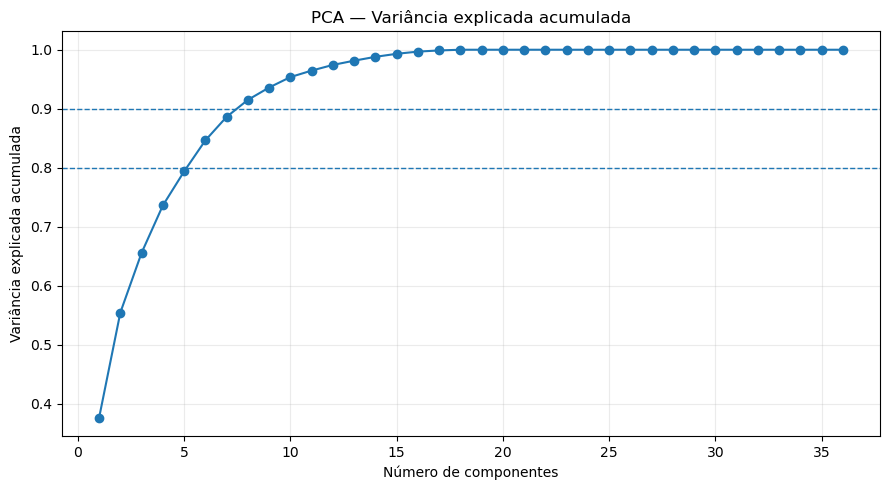

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(resumo_pca["COMPONENTE"], resumo_pca["VARIANCIA_ACUMULADA"], marker="o")
plt.axhline(0.80, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("PCA — Variância explicada acumulada")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "pca_variancia_acumulada.png", dpi=160, bbox_inches="tight")
plt.show()

In [13]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=colunas_modelo,
    columns=["PC1", "PC2"]
)
loadings["MAX_ABS"] = loadings.abs().max(axis=1)
loadings = loadings.sort_values("MAX_ABS", ascending=False)

print(f"PC1: {pca_2.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca_2.explained_variance_ratio_[1]:.2%}")
print(f"PC1 + PC2: {pca_2.explained_variance_ratio_.sum():.2%}")
loadings.head(12)

PC1: 37.61%
PC2: 17.84%
PC1 + PC2: 55.44%


,PC1,PC2,MAX_ABS
NIVEL_CHOQUE_SECA,-0.055927,0.333122,0.333122
NIVEL_SEGURANCA_CIVIS,-0.019860,-0.302928,0.302928
NIVEL_CHOQUE_PRECO_ALIMENTOS,-0.018231,-0.301256,0.301256
NIVEL_VIOLENCIA_POLITICA,-0.015963,-0.282614,0.282614
NIVEL_AGUA_NO_DOMICILIO,0.261424,0.038363,0.261424
NIVEL_TRATAMENTO_DIARREIA,-0.068708,0.260152,0.260152
NIVEL_MULHERES_ALFABETIZADAS,0.259262,-0.080548,0.259262
NIVEL_PRE_NATAL,0.253336,0.060688,0.253336
NIVEL_NECESSIDADE_ALIMENTOS,-0.080287,-0.252199,0.252199
NIVEL_FONTE_MELHORADA,0.249550,0.110371,0.249550


## 8. Escolha do número de clusters

São testadas soluções de `k=2` a `k=10` com quatro critérios:

- **Inertia / Elbow:** menor é melhor, procurando uma redução marginal progressivamente menor.
- **Silhouette:** maior é melhor.
- **Davies-Bouldin:** menor é melhor.
- **Calinski-Harabasz:** maior é melhor.

A escolha final não deve ser feita por uma única métrica. Neste dataset, soluções com muitos clusters apresentam melhor separação interna porque a estrutura dos indicadores é fortemente territorial e aproxima-se das províncias. Como o objectivo é obter **tipologias amplas** de qualidade de vida, é também necessário considerar parcimónia e interpretabilidade.

In [14]:
metricas_k = []
rotulos_por_k = {}

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels = modelo.fit_predict(X_scaled)
    rotulos_por_k[k] = labels
    metricas_k.append({
        "K": k,
        "INERTIA": modelo.inertia_,
        "SILHOUETTE": silhouette_score(X_scaled, labels),
        "DAVIES_BOULDIN": davies_bouldin_score(X_scaled, labels),
        "CALINSKI_HARABASZ": calinski_harabasz_score(X_scaled, labels),
        "NMI_PROVINCIA": normalized_mutual_info_score(pd.factorize(df["PROVINCIA"])[0], labels),
    })

metricas_k = pd.DataFrame(metricas_k)
metricas_k.round(4)

,K,INERTIA,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,NMI_PROVINCIA
0,2,3943.7587,0.3094,1.4453,70.8709,0.4528
1,3,3249.0725,0.3132,1.1617,59.4152,0.5882
2,4,2678.2371,0.3408,1.2259,58.7567,0.6942
3,5,2213.5429,0.3608,1.2575,61.0571,0.8124
4,6,1778.2962,0.4059,1.0937,67.8956,0.8509
5,7,1438.5276,0.4603,0.9508,75.4697,0.9012
6,8,1161.4293,0.4915,0.8297,84.7414,0.9292
7,9,909.3934,0.5409,0.7174,99.2682,0.9680
8,10,739.8299,0.5430,0.7211,111.5333,0.9957


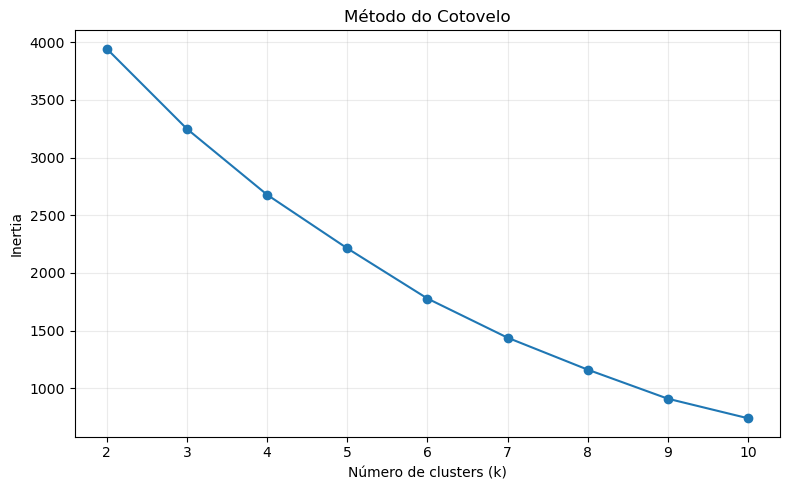

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(metricas_k["K"], metricas_k["INERTIA"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "kmeans_elbow.png", dpi=160, bbox_inches="tight")
plt.show()

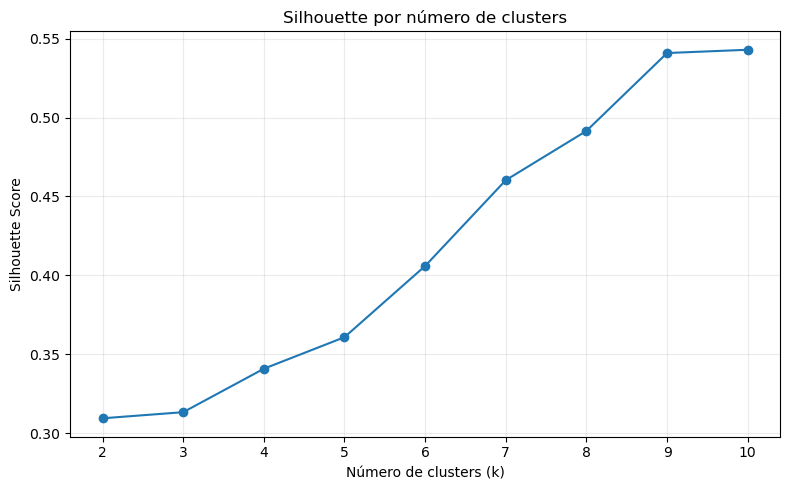

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(metricas_k["K"], metricas_k["SILHOUETTE"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette por número de clusters")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "kmeans_silhouette.png", dpi=160, bbox_inches="tight")
plt.show()

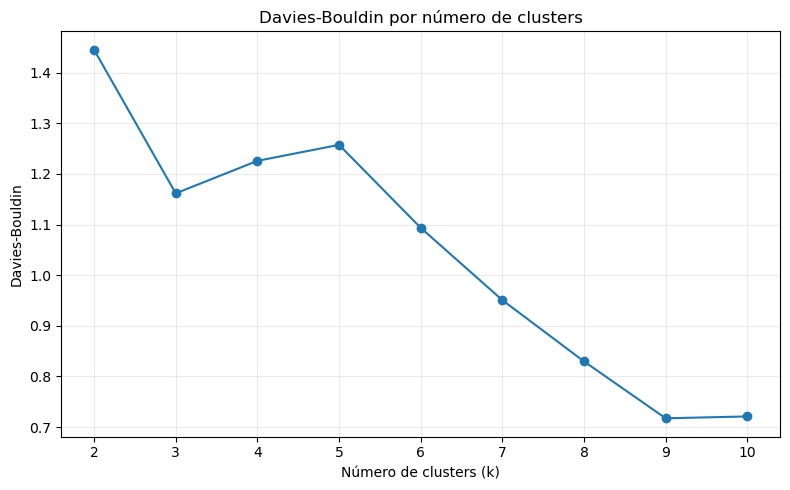

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(metricas_k["K"], metricas_k["DAVIES_BOULDIN"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin")
plt.title("Davies-Bouldin por número de clusters")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "kmeans_davies_bouldin.png", dpi=160, bbox_inches="tight")
plt.show()

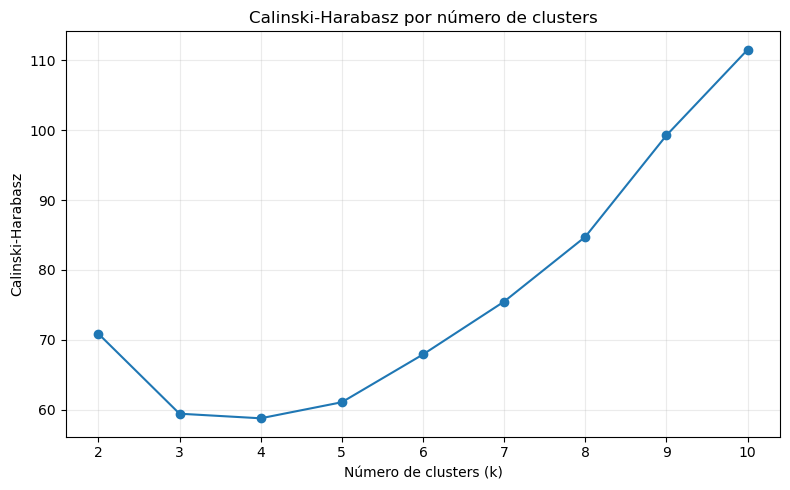

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(metricas_k["K"], metricas_k["CALINSKI_HARABASZ"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Calinski-Harabasz")
plt.title("Calinski-Harabasz por número de clusters")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "kmeans_calinski_harabasz.png", dpi=160, bbox_inches="tight")
plt.show()

### 8.1 Decisão: `k = 4`

Para este projecto, adopta-se **k=4** como compromisso entre:

1. criação de poucos perfis amplos e comunicáveis;
2. melhoria clara face a soluções muito pequenas;
3. prevenção de uma segmentação com 9–10 grupos que se aproxima fortemente de uma separação por província;
4. coerência com o objectivo de construir **classes relativas de qualidade de vida**, e não reproduzir divisões administrativas.

A decisão é, portanto, metodológica e substantiva, não apenas a maximização automática do Silhouette.

## 9. K-Means final

In [19]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=100)
clusters = kmeans.fit_predict(X_scaled)

df_resultado = df[["PROVINCIA", "DISTRITO"]].copy()
df_resultado["CLUSTER"] = clusters

metricas_final = {
    "K": K_FINAL,
    "INERTIA": kmeans.inertia_,
    "SILHOUETTE": silhouette_score(X_scaled, clusters),
    "DAVIES_BOULDIN": davies_bouldin_score(X_scaled, clusters),
    "CALINSKI_HARABASZ": calinski_harabasz_score(X_scaled, clusters),
}

pd.DataFrame([metricas_final]).round(4)

,K,INERTIA,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ
0,4,2678.2371,0.3408,1.2259,58.7567


In [20]:
print("Distritos por cluster:")
print(df_resultado["CLUSTER"].value_counts().sort_index())

Distritos por cluster:
CLUSTER
0    25
1    17
2    80
3    37
Name: count, dtype: int64


## 10. Estabilidade do modelo

Como o K-Means depende da inicialização dos centróides, a solução final é comparada com 50 execuções usando diferentes `random_state`. O **Adjusted Rand Index (ARI)** mede a concordância entre partições; valores próximos de 1 indicam elevada estabilidade.

In [21]:
ari_estabilidade = []
for seed in range(50):
    labels_seed = KMeans(n_clusters=K_FINAL, random_state=seed, n_init=20).fit_predict(X_scaled)
    ari_estabilidade.append(adjusted_rand_score(clusters, labels_seed))

estabilidade = pd.DataFrame({"SEED": range(50), "ARI": ari_estabilidade})
print(f"ARI médio:   {estabilidade['ARI'].mean():.4f}")
print(f"ARI mediano: {estabilidade['ARI'].median():.4f}")
print(f"ARI mínimo:  {estabilidade['ARI'].min():.4f}")
print(f"Execuções ARI=1: {(estabilidade['ARI'] == 1).sum()} / {len(estabilidade)}")

ARI médio:   0.9780
ARI mediano: 1.0000
ARI mínimo:  0.5791
Execuções ARI=1: 41 / 50


## 11. Construção de um score interpretativo de qualidade de vida

Os números dos clusters são arbitrários. Para ordenar os grupos numa escala relativa, é construído um **score interpretativo** apenas com indicadores cuja direcção normativa é suficientemente clara pelo nome da variável.

- Nos indicadores **positivos**, valores altos aumentam o score.
- Nos indicadores **negativos**, a escala é invertida (`6 - valor`), de modo que valores altos de vulnerabilidade reduzam o score.
- Vegetação, precipitação e `NIVEL_SEGURANCA_CIVIS` permanecem no K-Means, mas são excluídos do score por exigirem interpretação contextual adicional.

> O score **não participa na formação dos clusters**. É usado apenas depois do clustering para ordenar e interpretar os grupos.

In [22]:
indicadores_positivos = [
    "NIVEL_ACESSO_CUIDADOS_PRIMARIOS", "NIVEL_ACESSO_HOSPITAL", "NIVEL_ACESSO_EDUCACAO",
    "NIVEL_PRE_NATAL", "NIVEL_PARTO_UNIDADE", "NIVEL_POS_NATAL_MAE", "NIVEL_POS_NATAL_BEBE",
    "NIVEL_TRATAMENTO_DIARREIA", "NIVEL_MULHERES_ENSINO", "NIVEL_HOMENS_ENSINO",
    "NIVEL_MULHERES_ALFABETIZADAS", "NIVEL_HOMENS_ALFABETIZADOS", "NIVEL_ACESSO_AEREO",
    "NIVEL_FONTE_MELHORADA", "NIVEL_AGUA_CANALIZADA", "NIVEL_AGUA_NO_DOMICILIO",
    "NIVEL_TRATAMENTO_ADEQUADO", "NIVEL_RENDIMENTO",
]

indicadores_negativos = [
    "NIVEL_DE_PRECOS", "NIVEL_VIOLENCIA_POLITICA", "NIVEL_SEM_PRE_NATAL",
    "NIVEL_MULHERES_ANALFABETAS", "NIVEL_HOMENS_ANALFABETAS", "NIVEL_FONTE_NAO_MELHORADA",
    "NIVEL_CHOQUE_PRECO_ALIMENTOS", "NIVEL_CHOQUE_PRECO_COMBUSTIVEL", "NIVEL_CHOQUE_PERDA_EMPREGO",
    "NIVEL_CHOQUE_SECA", "NIVEL_CHOQUE_CHEIAS", "NIVEL_CHOQUE_DOENCA_MORTE",
    "NIVEL_NECESSIDADE_ALIMENTOS", "NIVEL_NECESSIDADE_DINHEIRO", "NIVEL_DE_POBREZA",
]

indicadores_contextuais = [
    "NIVEL_DE_VEGETACAO", "NIVEL_DE_PRECIPITACAO", "NIVEL_SEGURANCA_CIVIS"
]

linhas_direccao = []
for c in indicadores_positivos:
    linhas_direccao.append((c, "POSITIVO", "Incluído no score"))
for c in indicadores_negativos:
    linhas_direccao.append((c, "NEGATIVO", "Incluído com escala invertida"))
for c in indicadores_contextuais:
    linhas_direccao.append((c, "CONTEXTUAL", "Usado no K-Means; excluído do score"))
for c in remover:
    linhas_direccao.append((c, "REMOVIDO DO MODELO", "Constante ou redundância exacta"))

indicadores_direccao = pd.DataFrame(linhas_direccao, columns=["INDICADOR", "DIRECCAO", "USO"])
indicadores_direccao

,INDICADOR,DIRECCAO,USO
0,NIVEL_ACESSO_CUIDADOS_PRIMARIOS,POSITIVO,Incluído no score
1,NIVEL_ACESSO_HOSPITAL,POSITIVO,Incluído no score
2,NIVEL_ACESSO_EDUCACAO,POSITIVO,Incluído no score
3,NIVEL_PRE_NATAL,POSITIVO,Incluído no score
4,NIVEL_PARTO_UNIDADE,POSITIVO,Incluído no score
5,NIVEL_POS_NATAL_MAE,POSITIVO,Incluído no score
6,NIVEL_POS_NATAL_BEBE,POSITIVO,Incluído no score
7,NIVEL_TRATAMENTO_DIARREIA,POSITIVO,Incluído no score
8,NIVEL_MULHERES_ENSINO,POSITIVO,Incluído no score
9,NIVEL_HOMENS_ENSINO,POSITIVO,Incluído no score


In [23]:
X_alinhado = pd.DataFrame(index=df.index)
for c in indicadores_positivos:
    X_alinhado[c] = X_ord[c]
for c in indicadores_negativos:
    X_alinhado[c] = 6 - X_ord[c]

df_resultado["SCORE_QV"] = X_alinhado.mean(axis=1)

score_cluster = (
    df_resultado.groupby("CLUSTER")["SCORE_QV"]
    .agg(["mean", "std", "min", "max", "count"])
    .sort_values("mean")
)
score_cluster.round(3)

,mean,std,min,max,count
CLUSTER,,,,,
2,2.466,0.146,2.152,2.788,80
0,2.832,0.415,2.212,3.424,25
1,2.970,0.093,2.758,3.091,17
3,3.132,0.378,2.727,3.909,37


In [24]:
# Nomes relativos atribuídos pela ordem do score médio dos clusters.
nomes_relativos = [
    "Relativamente mais baixa",
    "Intermédia-baixa",
    "Intermédia-alta",
    "Relativamente mais alta",
]

ordem_clusters = score_cluster.index.tolist()
mapa_classe = {cluster: nomes_relativos[i] for i, cluster in enumerate(ordem_clusters)}
mapa_ordem = {cluster: i + 1 for i, cluster in enumerate(ordem_clusters)}

df_resultado["CLASSE_QV"] = df_resultado["CLUSTER"].map(mapa_classe)
df_resultado["ORDEM_QV"] = df_resultado["CLUSTER"].map(mapa_ordem)

df_resultado.groupby(["ORDEM_QV", "CLASSE_QV"], observed=True).agg(
    DISTRITOS=("DISTRITO", "count"),
    SCORE_MEDIO=("SCORE_QV", "mean")
).round(3)

,,DISTRITOS,SCORE_MEDIO
ORDEM_QV,CLASSE_QV,,
1,Relativamente mais baixa,80,2.466
2,Intermédia-baixa,25,2.832
3,Intermédia-alta,17,2.970
4,Relativamente mais alta,37,3.132


## 12. Perfil dos clusters

O perfil médio mantém a escala original de 1 a 5 para facilitar interpretação. Diferenças entre clusters devem ser lidas como diferenças relativas e não como percentagens populacionais.

In [25]:
perfil_clusters = X_modelo.copy()
perfil_clusters["CLUSTER"] = clusters
perfil_clusters = perfil_clusters.groupby("CLUSTER").mean().round(3)
perfil_clusters.insert(0, "CLASSE_QV", [mapa_classe[c] for c in perfil_clusters.index])
perfil_clusters

,CLASSE_QV,NIVEL_ACESSO_CUIDADOS_PRIMARIOS,NIVEL_ACESSO_HOSPITAL,NIVEL_ACESSO_EDUCACAO,NIVEL_DE_PRECOS,NIVEL_DE_VEGETACAO,NIVEL_DE_PRECIPITACAO,NIVEL_SEGURANCA_CIVIS,NIVEL_VIOLENCIA_POLITICA,NIVEL_PRE_NATAL,NIVEL_SEM_PRE_NATAL,NIVEL_PARTO_UNIDADE,NIVEL_POS_NATAL_MAE,NIVEL_POS_NATAL_BEBE,NIVEL_TRATAMENTO_DIARREIA,NIVEL_MULHERES_ENSINO,NIVEL_HOMENS_ENSINO,NIVEL_MULHERES_ALFABETIZADAS,NIVEL_HOMENS_ALFABETIZADOS,NIVEL_MULHERES_ANALFABETAS,NIVEL_HOMENS_ANALFABETAS,NIVEL_ACESSO_AEREO,NIVEL_FONTE_MELHORADA,NIVEL_AGUA_CANALIZADA,NIVEL_AGUA_NO_DOMICILIO,NIVEL_TRATAMENTO_ADEQUADO,NIVEL_FONTE_NAO_MELHORADA,NIVEL_RENDIMENTO,NIVEL_CHOQUE_PRECO_ALIMENTOS,NIVEL_CHOQUE_PRECO_COMBUSTIVEL,NIVEL_CHOQUE_PERDA_EMPREGO,NIVEL_CHOQUE_SECA,NIVEL_CHOQUE_CHEIAS,NIVEL_CHOQUE_DOENCA_MORTE,NIVEL_NECESSIDADE_ALIMENTOS,NIVEL_NECESSIDADE_DINHEIRO,NIVEL_DE_POBREZA
CLUSTER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,Intermédia-baixa,3.200,2.560,2.960,3.240,2.040,2.520,3.120,2.600,2.520,3.000,2.520,2.560,2.560,2.560,3.040,3.520,3.000,4.000,3.480,4.480,4.520,2.520,3.520,3.000,4.520,2.520,4.520,2.960,5.000,5.000,2.960,3.440,4.000,4.480,4.480,2.520
1,Intermédia-alta,4.353,3.765,3.412,2.294,1.588,1.294,1.353,1.235,3.000,4.000,1.000,2.000,2.000,5.000,1.000,1.000,1.000,1.000,2.000,2.000,4.000,3.000,4.000,2.000,3.000,4.000,2.000,2.000,1.000,2.000,5.000,5.000,2.000,1.000,1.000,4.000
2,Relativamente mais baixa,2.562,2.238,2.525,4.100,3.288,2.700,3.900,3.588,1.238,1.525,1.662,1.662,1.612,3.138,1.475,1.525,1.425,1.525,1.612,1.762,4.475,1.188,1.288,1.188,1.662,1.800,3.525,3.762,3.000,3.375,2.812,3.575,2.525,4.138,2.612,4.338
3,Relativamente mais alta,2.892,3.405,3.270,2.568,3.162,3.622,3.757,3.541,4.243,4.622,4.243,4.216,4.216,2.027,3.865,3.865,4.243,3.486,4.622,3.865,3.649,4.243,2.730,4.243,2.135,4.243,1.054,4.027,2.838,2.892,2.351,2.189,3.108,2.351,4.081,1.378


In [26]:
# Indicadores que mais distinguem cada cluster em relação à média nacional,
# medidos na escala padronizada.
centroides_z = pd.DataFrame(kmeans.cluster_centers_, columns=colunas_modelo)
linhas_distintivas = []
for cluster in range(K_FINAL):
    s = centroides_z.loc[cluster]
    for indicador in s.abs().sort_values(ascending=False).head(6).index:
        linhas_distintivas.append({
            "CLUSTER": cluster,
            "CLASSE_QV": mapa_classe[cluster],
            "INDICADOR": indicador,
            "DESVIO_Z": s[indicador],
            "SENTIDO": "Acima da média" if s[indicador] > 0 else "Abaixo da média",
        })

distintivos = pd.DataFrame(linhas_distintivas)
distintivos

,CLUSTER,CLASSE_QV,INDICADOR,DESVIO_Z,SENTIDO
0,0,Intermédia-baixa,NIVEL_TRATAMENTO_ADEQUADO,1.645258,Acima da média
1,0,Intermédia-baixa,NIVEL_HOMENS_ALFABETIZADOS,1.348864,Acima da média
2,0,Intermédia-baixa,NIVEL_HOMENS_ANALFABETAS,1.316782,Acima da média
3,0,Intermédia-baixa,NIVEL_CHOQUE_PERDA_EMPREGO,1.296200,Acima da média
4,0,Intermédia-baixa,NIVEL_CHOQUE_PRECO_COMBUSTIVEL,1.288489,Acima da média
5,0,Intermédia-baixa,NIVEL_RENDIMENTO,1.049983,Acima da média
6,1,Intermédia-alta,NIVEL_NECESSIDADE_ALIMENTOS,-1.828521,Abaixo da média
7,1,Intermédia-alta,NIVEL_SEGURANCA_CIVIS,-1.704690,Abaixo da média
8,1,Intermédia-alta,NIVEL_VIOLENCIA_POLITICA,-1.523349,Abaixo da média
9,1,Intermédia-alta,NIVEL_TRATAMENTO_DIARREIA,1.490292,Acima da média


## 13. Relação entre clusters e províncias

Esta análise verifica se os clusters estão a capturar apenas diferenças administrativas. Uma associação territorial elevada não invalida o modelo, mas muda a interpretação: indica que os perfis socioeconómicos possuem forte estrutura espacial.

In [27]:
tabela_provincia_cluster = pd.crosstab(df_resultado["PROVINCIA"], df_resultado["CLASSE_QV"])
tabela_provincia_cluster

CLASSE_QV,Intermédia-alta,Intermédia-baixa,Relativamente mais alta,Relativamente mais baixa
PROVINCIA,,,,
Cabo Delgado,17,0,0,0
Gaza,0,0,14,0
Inhambane,0,0,14,0
Manica,0,12,0,0
Maputo,0,0,8,0
Maputo City,0,0,1,0
Nampula,0,0,0,23
Niassa,0,0,0,19
Sofala,0,13,0,0


In [28]:
nmi_provincia = normalized_mutual_info_score(
    pd.factorize(df_resultado["PROVINCIA"])[0],
    df_resultado["CLUSTER"]
)
print(f"NMI Província × Cluster: {nmi_provincia:.4f}")

NMI Província × Cluster: 0.6942


## 14. Visualização final dos clusters em PCA

O gráfico abaixo projecta os 36 indicadores do modelo nas duas primeiras componentes principais. É apenas uma visualização 2D; a separação real do K-Means foi calculada no espaço padronizado completo.

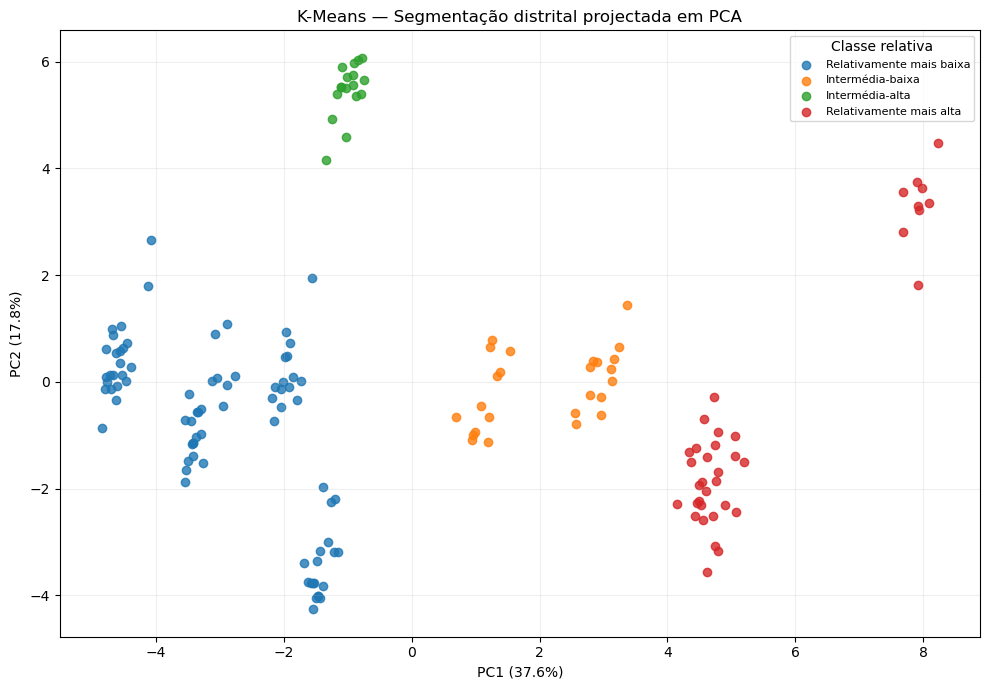

In [29]:
pca_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "CLUSTER": clusters,
    "CLASSE_QV": df_resultado["CLASSE_QV"],
})

plt.figure(figsize=(10, 7))
for classe in nomes_relativos:
    mask = pca_plot["CLASSE_QV"] == classe
    plt.scatter(pca_plot.loc[mask, "PC1"], pca_plot.loc[mask, "PC2"], label=classe, alpha=0.8)
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.1%})")
plt.title("K-Means — Segmentação distrital projectada em PCA")
plt.legend(title="Classe relativa", fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "pca_clusters_kmeans.png", dpi=180, bbox_inches="tight")
plt.show()

## 15. Resultados principais

Os resultados devem ser interpretados em conjunto:

- `k=4` fornece quatro tipologias amplas e interpretáveis.
- O Silhouette indica separação moderada, compatível com a sobreposição esperada entre condições socioeconómicas distritais.
- A PCA mostra quanto da variação é captada por duas dimensões, mas o K-Means usa todas as variáveis seleccionadas.
- O teste de ARI avalia se a solução é robusta a diferentes inicializações.
- A análise por província evidencia a componente territorial dos agrupamentos.
- As classes de qualidade de vida são **relativas ao próprio conjunto de 159 distritos** e são ordenadas por um score interpretativo pós-clustering.

In [30]:
resumo_final = pd.DataFrame({
    "INDICADOR": [
        "Distritos", "Indicadores originais", "Indicadores no K-Means", "k final",
        "Silhouette", "Davies-Bouldin", "Calinski-Harabasz",
        "Variância PCA PC1+PC2", "ARI médio (50 inicializações)", "NMI Província × Cluster"
    ],
    "VALOR": [
        len(df), len(colunas_indicadores_originais), len(colunas_modelo), K_FINAL,
        metricas_final["SILHOUETTE"], metricas_final["DAVIES_BOULDIN"],
        metricas_final["CALINSKI_HARABASZ"], pca_2.explained_variance_ratio_.sum(),
        estabilidade["ARI"].mean(), nmi_provincia
    ]
})
resumo_final

,INDICADOR,VALOR
0,Distritos,159.000000
1,Indicadores originais,38.000000
2,Indicadores no K-Means,36.000000
3,k final,4.000000
4,Silhouette,0.340777
5,Davies-Bouldin,1.225872
6,Calinski-Harabasz,58.756715
7,Variância PCA PC1+PC2,0.554445
8,ARI médio (50 inicializações),0.978009
9,NMI Província × Cluster,0.694229


## 16. Limitações

1. **Escala ordinal:** a transformação 1–5 assume intervalos comparáveis entre categorias.
2. **K-Means e distância euclidiana:** o algoritmo favorece clusters compactos e aproximadamente esféricos.
3. **Peso dos indicadores:** após padronização, cada indicador recebe peso estatístico semelhante; isso não corresponde necessariamente à importância social de cada dimensão.
4. **Correlação entre indicadores:** permanecem variáveis fortemente relacionadas porque representam dimensões conceptualmente distintas, podendo aumentar o peso de certos domínios.
5. **Score interpretativo:** a direcção positiva/negativa é uma regra analítica explícita; variáveis contextuais foram excluídas do score para evitar uma interpretação normativa excessiva.
6. **Estrutura territorial:** parte relevante da separação dos clusters coincide com diferenças provinciais.
7. **Sem causalidade:** o clustering descreve semelhanças; não demonstra que um indicador causa determinada condição de qualidade de vida.
8. **Classificação relativa:** “mais alta” ou “mais baixa” significa apenas posição relativa dentro deste dataset.


## 17. Conclusão

A aplicação do K-Means permite condensar um conjunto multidimensional de indicadores em quatro perfis distritais amplos. A solução final privilegia interpretação e utilidade analítica, em vez de maximizar isoladamente uma métrica de clustering. Os resultados mostram que as condições distritais não se distribuem aleatoriamente: existe uma componente territorial relevante, mas os quatro grupos oferecem uma síntese mais ampla do que uma simples separação por província.

A classificação final deve ser usada como **ferramenta exploratória de segmentação e priorização**, acompanhada pelos perfis de indicadores de cada cluster e pelas limitações descritas acima.

## 18. Exportação dos resultados

In [32]:
# Resultado por distrito
final_export = df_resultado.sort_values(["ORDEM_QV", "PROVINCIA", "DISTRITO"]).copy()
final_export.to_csv(PASTA_RESULTADOS / "distritos_clusters.csv", index=False, encoding="utf-8-sig")

# Perfis
perfil_clusters.to_csv(PASTA_RESULTADOS / "perfil_clusters.csv", encoding="utf-8-sig")

# Métricas para diferentes k
metricas_k.to_csv(PASTA_RESULTADOS / "metricas_kmeans.csv", index=False, encoding="utf-8-sig")

# PCA
loadings.drop(columns="MAX_ABS").to_csv(PASTA_RESULTADOS / "loadings_pca.csv", encoding="utf-8-sig")

# Correlações
correlacoes_altas.to_csv(PASTA_RESULTADOS / "correlacoes_altas.csv", index=False, encoding="utf-8-sig")

# Regras de direcção
indicadores_direccao.to_csv(PASTA_RESULTADOS / "indicadores_direccao.csv", index=False, encoding="utf-8-sig")

# Indicadores distintivos
_dist = distintivos.copy()
_dist["DESVIO_Z"] = _dist["DESVIO_Z"].round(4)
_dist.to_csv(PASTA_RESULTADOS / "indicadores_distintivos_clusters.csv", index=False, encoding="utf-8-sig")

# Resumo final
resumo_final.to_csv(PASTA_RESULTADOS / "resumo_metricas_final.csv", index=False, encoding="utf-8-sig")

print("Ficheiros exportados:")
for p in sorted(PASTA_RESULTADOS.iterdir()):
    print("-", p.name)

Ficheiros exportados:
- correlacoes_altas.csv
- distritos_clusters.csv
- indicadores_direccao.csv
- indicadores_distintivos_clusters.csv
- kmeans_calinski_harabasz.png
- kmeans_davies_bouldin.png
- kmeans_elbow.png
- kmeans_silhouette.png
- loadings_pca.csv
- metricas_kmeans.csv
- pca_clusters_kmeans.png
- pca_variancia_acumulada.png
- perfil_clusters.csv
- resumo_metricas_final.csv
